Por favor, selecciona tu archivo CSV:


Saving lecturas_hivemq.csv to lecturas_hivemq (10).csv


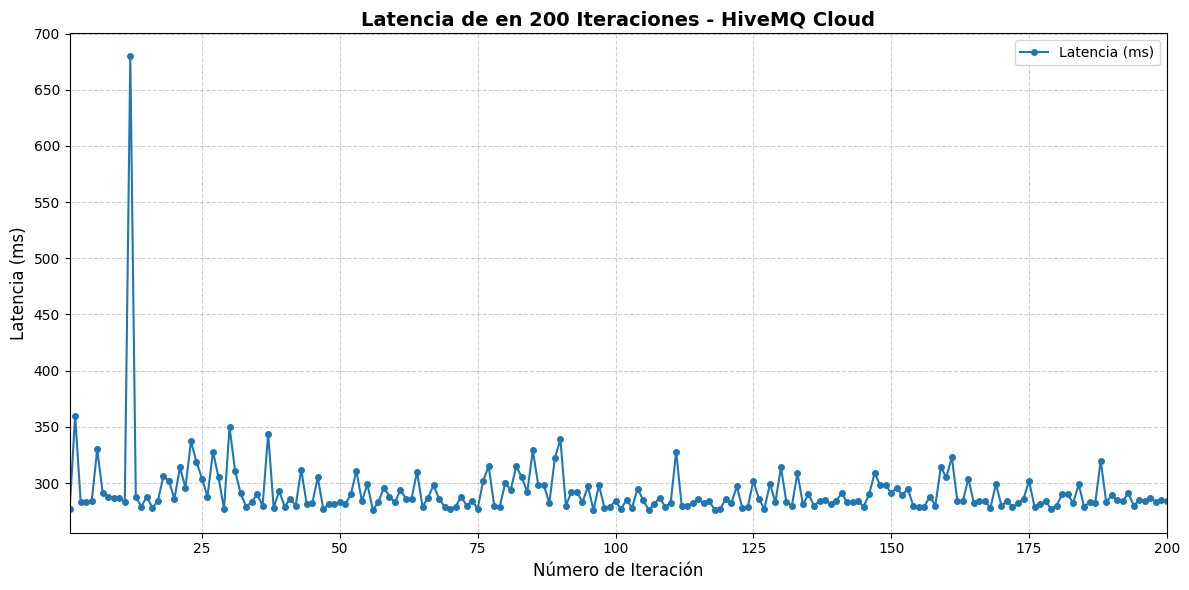

In [19]:
# ==========================================
# Script para graficar latencia en Google Colab
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1. Subir el archivo CSV desde tu computadora
print("Por favor, selecciona tu archivo CSV:")
uploaded = files.upload()

# Obtener el nombre del archivo subido
file_name = list(uploaded.keys())[0]

# 2. Nombres de columnas según el orden especificado
column_names = [
    'Instante_calculo_latencia',
    'Instante_emision_ESP32',
    'Instante_emision_ESP32_corregido',
    'Offset_calibracion',
    'Latencia'
]

# 3. Cargar el CSV (asumiendo que usa comas como separador)
# Si tu archivo utiliza punto y coma, cambia sep=',' por sep=';'
df = pd.read_csv(file_name, header=None, names=column_names, sep=',')

# 4. Seleccionar las primeras 200 iteraciones
df_first_200 = df.head(200)

# 5. Generar el gráfico de latencia
plt.figure(figsize=(12, 6))

# Graficar la latencia de las primeras 200 iteraciones
plt.plot(df_first_200.index + 1, df_first_200['Latencia'], marker='o', linestyle='-', color='#1f77b4', markersize=4, label='Latencia (ms)')

# Configuración visual e información del gráfico
plt.title('Latencia de en 200 Iteraciones - HiveMQ Cloud', fontsize=14, fontweight='bold')
plt.xlabel('Número de Iteración', fontsize=12)
plt.ylabel('Latencia (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajuste dinámico de límites del eje X
plt.xlim(1, 200)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Por favor, selecciona tu archivo CSV:


Saving lecturas_mosquitto.csv to lecturas_mosquitto (8).csv


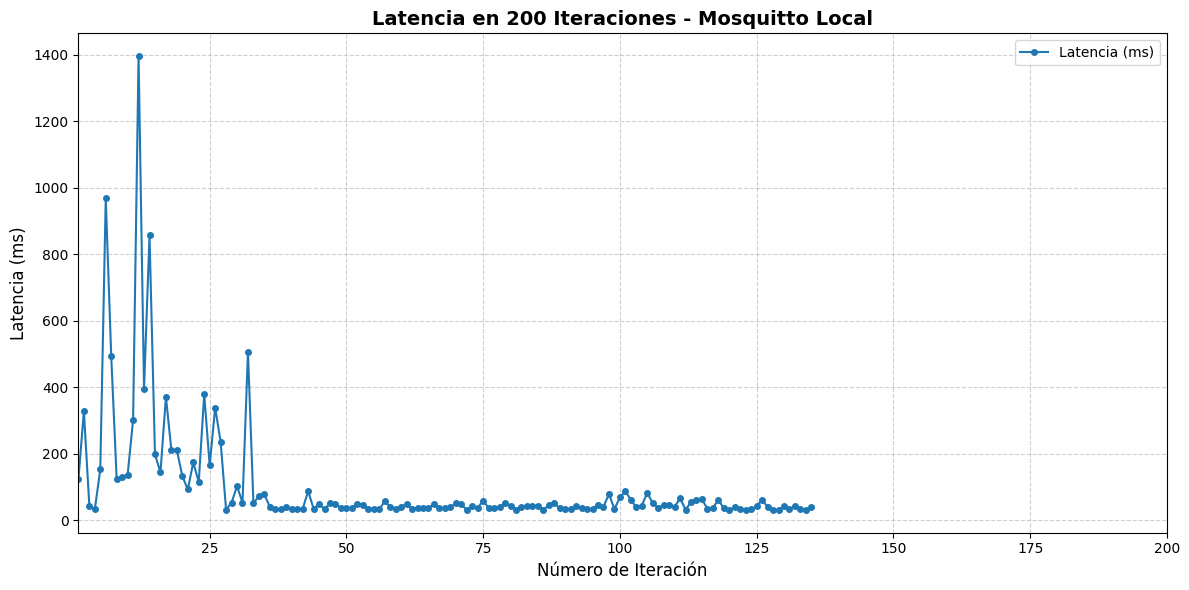

In [18]:
# ==========================================
# Script para graficar latencia en Google Colab
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1. Subir el archivo CSV desde tu computadora
print("Por favor, selecciona tu archivo CSV:")
uploaded = files.upload()

# Obtener el nombre del archivo subido
file_name = list(uploaded.keys())[0]

# 2. Nombres de columnas según el orden especificado
column_names = [
    'Instante_calculo_latencia',
    'Instante_emision_ESP32',
    'Instante_emision_ESP32_corregido',
    'Offset_calibracion',
    'Latencia'
]

# 3. Cargar el CSV (asumiendo que usa comas como separador)
# Si tu archivo utiliza punto y coma, cambia sep=',' por sep=';'
df = pd.read_csv(file_name, header=None, names=column_names, sep=',')

# 4. Seleccionar las primeras 200 iteraciones
df_first_200 = df.head(200)

# 5. Generar el gráfico de latencia
plt.figure(figsize=(12, 6))

# Graficar la latencia de las primeras 200 iteraciones
plt.plot(df_first_200.index + 1, df_first_200['Latencia'], marker='o', linestyle='-', color='#1f77b4', markersize=4, label='Latencia (ms)')

# Configuración visual e información del gráfico
plt.title('Latencia en 200 Iteraciones - Mosquitto Local', fontsize=14, fontweight='bold')
plt.xlabel('Número de Iteración', fontsize=12)
plt.ylabel('Latencia (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajuste dinámico de límites del eje X
plt.xlim(1, 200)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

--- PRIMER ARCHIVO ---
Por favor, selecciona el primer archivo CSV (ej. Mosquitto Local):


Saving lecturas_mosquitto.csv to lecturas_mosquitto (6).csv

--- SEGUNDO ARCHIVO ---
Por favor, selecciona el segundo archivo CSV (ej. HiveMQ Cloud):


Saving lecturas_hivemq.csv to lecturas_hivemq (9).csv

 MÉTRICAS (200 ITERACIONES)
[Mosquitto Local]  Min: 4 ms | Mediana: 14.0 ms | Max: 224 ms
[HiveMQ Cloud]  Min: 276 ms | Mediana: 284.5 ms | Max: 680 ms



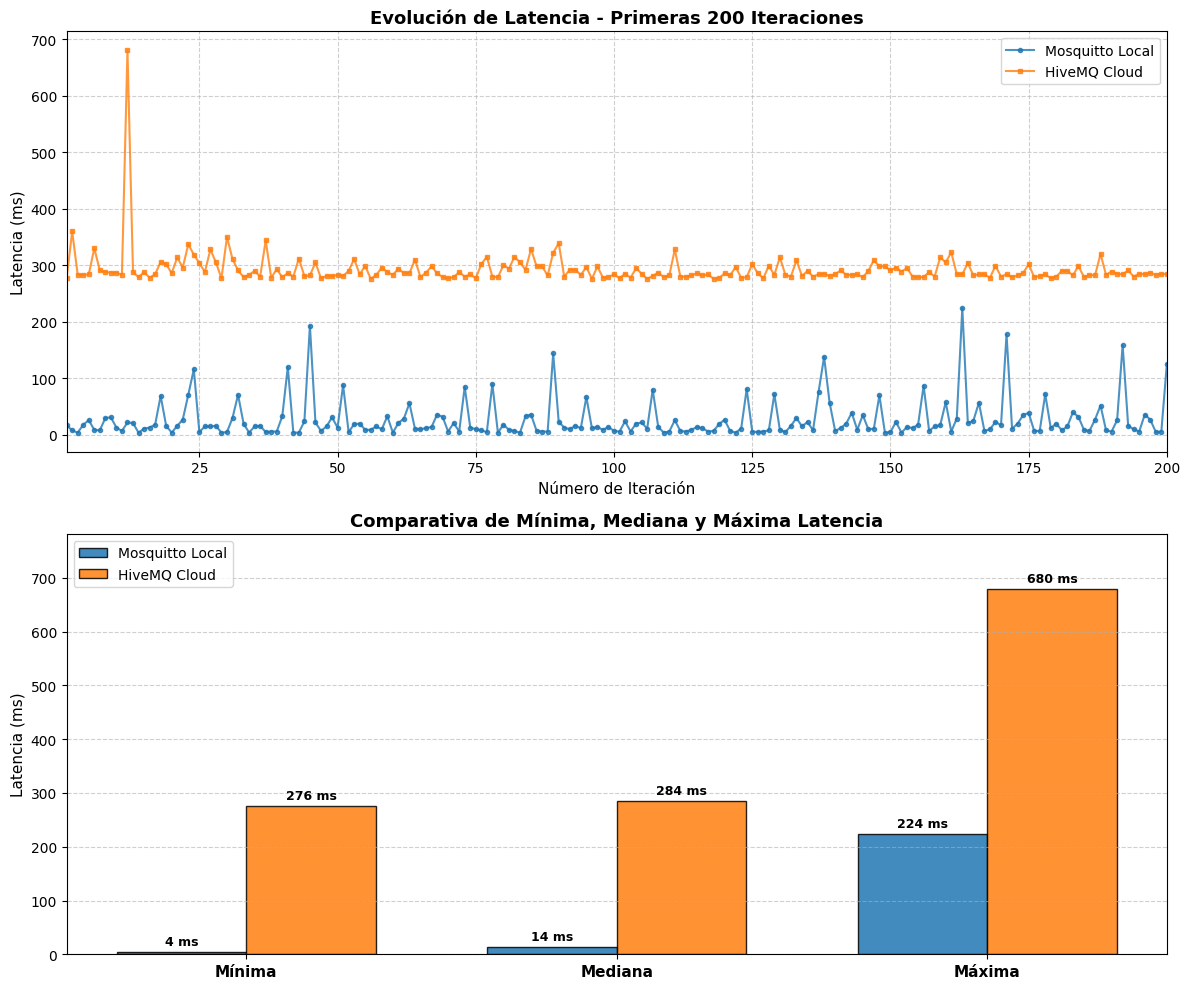

In [16]:
# ====================================================================
# Script para Comparar 2 CSVs: Evolución + Barras (Min, Mediana, Max)
# ====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# 1. Estructura de columnas
column_names = [
    'Instante_calculo_latencia',
    'Instante_emision_ESP32',
    'Instante_emision_ESP32_corregido',
    'Offset_calibracion',
    'Latencia'
]

# 2. Carga manual del PRIMER archivo CSV
print("--- PRIMER ARCHIVO ---")
print("Por favor, selecciona el primer archivo CSV (ej. Mosquitto Local):")
uploaded_1 = files.upload()
file_name_1 = list(uploaded_1.keys())[0]

# 3. Carga manual del SEGUNDO archivo CSV
print("\n--- SEGUNDO ARCHIVO ---")
print("Por favor, selecciona el segundo archivo CSV (ej. HiveMQ Cloud):")
uploaded_2 = files.upload()
file_name_2 = list(uploaded_2.keys())[0]

# 4. Procesar los archivos (Tomar únicamente las primeras 200 filas)
df1_200 = pd.read_csv(file_name_1, header=None, names=column_names, sep=',').head(200)
df2_200 = pd.read_csv(file_name_2, header=None, names=column_names, sep=',').head(200)

# 5. Calcular estadísticas de las primeras 200 filas
stats1 = [df1_200['Latencia'].min(), df1_200['Latencia'].median(), df1_200['Latencia'].max()]
stats2 = [df2_200['Latencia'].min(), df2_200['Latencia'].median(), df2_200['Latencia'].max()]

# Imprimir métricas en consola
print("\n" + "="*50)
print(f" MÉTRICAS (200 ITERACIONES)")
print("="*50)
print(f"[Mosquitto Local]  Min: {stats1[0]} ms | Mediana: {stats1[1]} ms | Max: {stats1[2]} ms")
print(f"[HiveMQ Cloud]  Min: {stats2[0]} ms | Mediana: {stats2[1]} ms | Max: {stats2[2]} ms")
print("="*50 + "\n")

# ====================================================================
# 6. GENERACIÓN DE LA FIGURA CON DOS SUBGRÁFICOS
# ====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --------------------------------------------------------------------
# GRÁFICO 1: EVOLUCIÓN DE LA LATENCIA (200 MUESTRAS)
# --------------------------------------------------------------------
ax1.plot(df1_200.index + 1, df1_200['Latencia'], marker='o', linestyle='-', color='#1f77b4', markersize=3, alpha=0.8, label=f'Mosquitto Local')
ax1.plot(df2_200.index + 1, df2_200['Latencia'], marker='s', linestyle='-', color='#ff7f0e', markersize=3, alpha=0.8, label=f'HiveMQ Cloud')

ax1.set_title('Evolución de Latencia - Primeras 200 Iteraciones', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Iteración', fontsize=11)
ax1.set_ylabel('Latencia (ms)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)
ax1.set_xlim(1, 200)

# --------------------------------------------------------------------
# GRÁFICO 2: BARRAS COMPARATIVAS (MÍNIMA, MEDIANA, MÁXIMA)
# --------------------------------------------------------------------
metricas = ['Mínima', 'Mediana', 'Máxima']
x = np.arange(len(metricas))
ancho_barra = 0.35

rects1 = ax2.bar(x - ancho_barra/2, stats1, ancho_barra, label="Mosquitto Local", color='#1f77b4', edgecolor='black', alpha=0.85)
rects2 = ax2.bar(x + ancho_barra/2, stats2, ancho_barra, label="HiveMQ Cloud", color='#ff7f0e', edgecolor='black', alpha=0.85)

ax2.set_title('Comparativa de Mínima, Mediana y Máxima Latencia', fontsize=13, fontweight='bold')
ax2.set_ylabel('Latencia (ms)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(metricas, fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Función para añadir etiquetas con valores numéricos sobre cada barra
def agregar_etiquetas(rects):
    for rect in rects:
        altura = rect.get_height()
        ax2.annotate(f'{int(altura)} ms',
                    xy=(rect.get_x() + rect.get_width() / 2, altura),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

agregar_etiquetas(rects1)
agregar_etiquetas(rects2)

# Ajuste de escala vertical para evitar colisión de texto con los bordes
limite_superior = max(max(stats1), max(stats2)) * 1.15
ax2.set_ylim(0, limite_superior)

# Mostrar figura
plt.tight_layout()
plt.show()